## Volume Profile

## TPO Profile

##### 

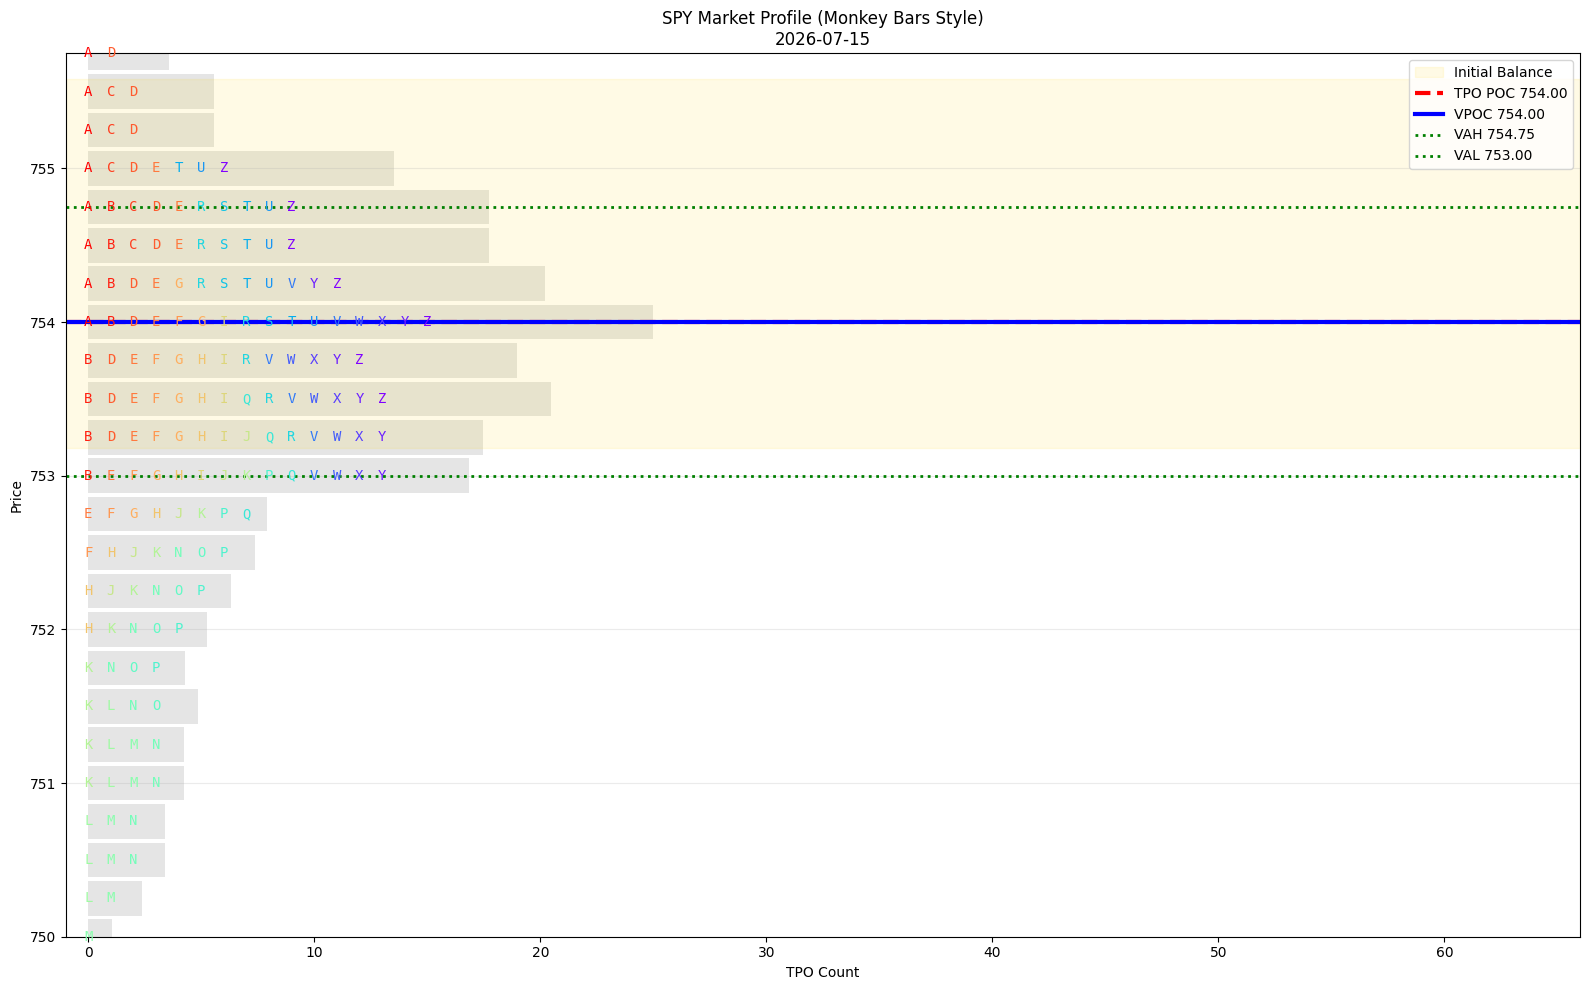

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ==========================================================
# SETTINGS
# ==========================================================

ticker = "SPY"

period = "5d"
interval = "15m"      # 15-minute TPO periods

tick_size = 0.25

# ==========================================================
# DOWNLOAD DATA
# ==========================================================

data = yf.download(
    ticker,
    period=period,
    interval=interval,
    auto_adjust=True,
    progress=False
)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Use most recent trading day only
latest_date = sorted(set(data.index.date))[-1]
day_data = data[data.index.date == latest_date].copy()

# ==========================================================
# PRICE BINS
# ==========================================================

min_price = np.floor(day_data['Low'].min() / tick_size) * tick_size
max_price = np.ceil(day_data['High'].max() / tick_size) * tick_size

price_bins = np.arange(
    min_price,
    max_price + tick_size,
    tick_size
)

# ==========================================================
# BUILD TPO + VOLUME PROFILES
# ==========================================================

tpo_dict = {price: [] for price in price_bins}
volume_profile = {price: 0.0 for price in price_bins}

alphabet = [chr(i) for i in range(ord('A'), ord('Z') + 1)]

for i, (_, row) in enumerate(day_data.iterrows()):

    letter = alphabet[i % len(alphabet)]

    bar_low = np.floor(row['Low'] / tick_size) * tick_size
    bar_high = np.ceil(row['High'] / tick_size) * tick_size

    prices = np.arange(
        bar_low,
        bar_high + tick_size,
        tick_size
    )

    if len(prices) == 0:
        continue

    vol_per_level = row['Volume'] / len(prices)

    for p in prices:

        if p in tpo_dict:
            tpo_dict[p].append(letter)

        if p in volume_profile:
            volume_profile[p] += vol_per_level

# ==========================================================
# CREATE DATAFRAME
# ==========================================================

profile_df = pd.DataFrame({
    'Price': list(tpo_dict.keys()),
    'TPOs': [sorted(list(set(v))) for v in tpo_dict.values()],
    'Count': [len(set(v)) for v in tpo_dict.values()]
})

profile_df = profile_df[
    profile_df['Count'] > 0
].sort_values(
    by='Price',
    ascending=False
)

# ==========================================================
# TPO POC
# ==========================================================

tpo_poc = profile_df.loc[
    profile_df['Count'].idxmax(),
    'Price'
]

# ==========================================================
# VOLUME POC
# ==========================================================

volume_series = pd.Series(volume_profile)

vpoc = volume_series.idxmax()

# ==========================================================
# VALUE AREA (70%)
# ==========================================================

target_volume = volume_series.sum() * 0.70

sorted_vol = volume_series.sort_values(
    ascending=False
)

cum_vol = sorted_vol.cumsum()

value_area = sorted_vol[
    cum_vol <= target_volume
]

VAH = value_area.index.max()
VAL = value_area.index.min()

# ==========================================================
# RAINBOW LETTER COLORS
# A = RED
# Z = VIOLET
# ==========================================================

letter_colors = {
    letter: cm.rainbow(
        1 - i/(len(alphabet)-1)
    )
    for i, letter in enumerate(alphabet)
}

# ==========================================================
# INITIAL BALANCE
# (First Hour = A+B periods)
# ==========================================================

A_high = day_data.iloc[:2]['High'].max()
A_low = day_data.iloc[:2]['Low'].min()

# ==========================================================
# PLOT
# ==========================================================

fig, ax = plt.subplots(
    figsize=(16, 10)
)

# ----------------------------------------------------------
# Volume profile background
# ----------------------------------------------------------

max_volume = max(volume_profile.values())

for price, vol in volume_profile.items():

    width = vol / max_volume * 25

    ax.barh(
        price,
        width,
        height=tick_size * 0.9,
        alpha=0.20,
        color='gray',
        zorder=1
    )

# ----------------------------------------------------------
# TPO Letters
# ----------------------------------------------------------

for _, row in profile_df.iterrows():

    letters = row['TPOs']

    for x, letter in enumerate(letters):

        ax.text(
            x,
            row['Price'],
            letter,
            fontsize=10,
            fontfamily='monospace',
            ha='center',
            va='center',
            color=letter_colors[letter],
            zorder=5
        )

# ----------------------------------------------------------
# Initial Balance
# ----------------------------------------------------------

ax.axhspan(
    A_low,
    A_high,
    alpha=0.10,
    color='gold',
    label='Initial Balance'
)

# ----------------------------------------------------------
# TPO POC
# ----------------------------------------------------------

ax.axhline(
    tpo_poc,
    linewidth=3,
    linestyle='--',
    color='red',
    label=f'TPO POC {tpo_poc:.2f}'
)

# ----------------------------------------------------------
# Volume POC
# ----------------------------------------------------------

ax.axhline(
    vpoc,
    linewidth=3,
    linestyle='-',
    color='blue',
    label=f'VPOC {vpoc:.2f}'
)

# ----------------------------------------------------------
# Value Area
# ----------------------------------------------------------

ax.axhline(
    VAH,
    linestyle=':',
    linewidth=2,
    color='green',
    label=f'VAH {VAH:.2f}'
)

ax.axhline(
    VAL,
    linestyle=':',
    linewidth=2,
    color='green',
    label=f'VAL {VAL:.2f}'
)

# ==========================================================
# FORMATTING
# ==========================================================

max_letters = profile_df['Count'].max()

ax.set_xlim(
    -1,
    max_letters + 50
)

ax.set_ylim(
    min_price,
    max_price
)

ax.set_title(
    f"{ticker} Market Profile (Monkey Bars Style)\n{latest_date}"
)

ax.set_ylabel("Price")
ax.set_xlabel("TPO Count")

ax.grid(
    axis='y',
    alpha=0.25
)

ax.legend(
    loc='upper right'
)

plt.tight_layout()
plt.show()

In [9]:
latest_date

datetime.date(2026, 7, 14)

In [190]:
data.index.date[-1]

datetime.date(2026, 6, 18)